# Car Price Prediction Dataset — End-to-End Machine Learning Pipeline

Welcome to this data science journey! In this notebook, we will act as data scientists exploring the CarDekho dataset. We will uncover insights through Exploratory Data Analysis (EDA), handle missing data with logical assumptions, perform feature engineering, and finally, build a robust Machine Learning Pipeline to predict car prices. 

Let's get started!

## Q1. How do we load our dataset and get our first look at the data?

The first step in any data science project is to load the data into a Pandas DataFrame and inspect the first few rows to understand what we are working with.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('CarDekho.csv')
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


## Q2. What are the data types and where are the missing values?

Before we can analyze or model the data, we must understand its structure. Are the numerical columns actually stored as numbers? Do we have missing values that need our attention?

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [3]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

## Q3. Feature Engineering: How do we clean string features into usable numbers?

Looking at the output above, columns like `Engine`, `Max Power`, and `Max Torque` are stored as strings (objects) because they contain units like 'cc' and 'bhp'. Machine learning models require pure numbers. 

We need to engineer these features by extracting the numerical portions. We will use string manipulation to remove the text and convert the results into floating-point numbers.

In [4]:
df['Engine'] = df['Engine'].str.replace(' cc', '', regex=False).astype(float)
df['Max Power'] = df['Max Power'].str.extract(r'([\d\.]+)').astype(float)
df['Max Torque'] = df['Max Torque'].str.extract(r'([\d\.]+)').astype(float)

df[['Engine', 'Max Power', 'Max Torque']].head()

,Engine,Max Power,Max Torque
0,1198.0,87.0,109.0000
1,1248.0,74.0,190.0000
2,1197.0,79.0,112.7619
3,1197.0,82.0,113.0000
4,2393.0,148.0,343.0000


## Q4. Logical Imputation: How do we handle missing values for Electric Vehicles?

We noticed missing values in the Engine and Max Power columns. If we simply drop all rows with missing values, we might lose valuable data. 

As data scientists, we must apply domain knowledge. Electric vehicles (EVs) do not have an internal combustion engine, meaning they lack an 'Engine' capacity in 'cc'. Therefore, their values are naturally missing! 

Instead of dropping EVs, we will logically fill their missing engine and power statistics with 0. For standard combustion cars with missing critical specs, we will drop those rows as they represent incomplete records.

In [5]:
is_electric = df['Fuel Type'] == 'Electric'
df.loc[is_electric, ['Engine', 'Max Power', 'Max Torque']] = df.loc[is_electric, ['Engine', 'Max Power', 'Max Torque']].fillna(0)

df = df.dropna(subset=['Engine', 'Max Power'])

print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 Make                   0
Model                  0
Price                  0
Year                   0
Kilometer              0
Fuel Type              0
Transmission           0
Location               0
Color                  0
Owner                  0
Seller Type            0
Engine                 0
Max Power              0
Max Torque             0
Drivetrain            63
Length                 0
Width                  0
Height                 0
Seating Capacity       0
Fuel Tank Capacity    49
dtype: int64


## Q5. EDA: What does the distribution of our target variable (Price) look like?

Now that our data is cleaner, let's explore our target variable: the Price. Car prices often suffer from severe positive skewness (meaning there are a few extremely expensive luxury cars that stretch the data). 

Let's visualize this using a logarithmic scale to normalize the visual distribution. If the data is highly skewed, models like Random Forest are great choices as they are robust to non-linear and skewed relationships!

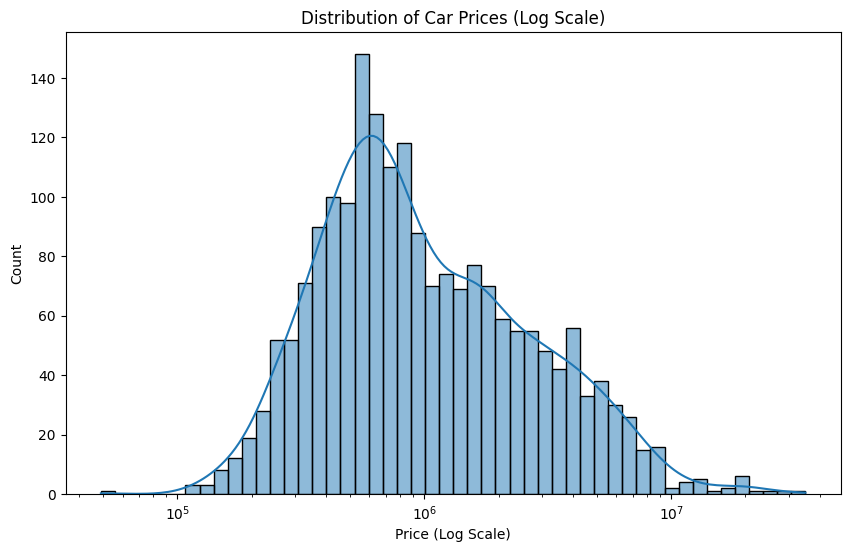

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of Car Prices (Log Scale)')
plt.xlabel('Price (Log Scale)')
plt.ylabel('Count')
plt.show()

## Q6. EDA: How does the car price vary based on the fuel type?

Let's explore how categorical variables affect our target. Does a specific fuel type command a higher price? We will use a boxplot on a log scale to compare the median prices and variances across different fuel types.

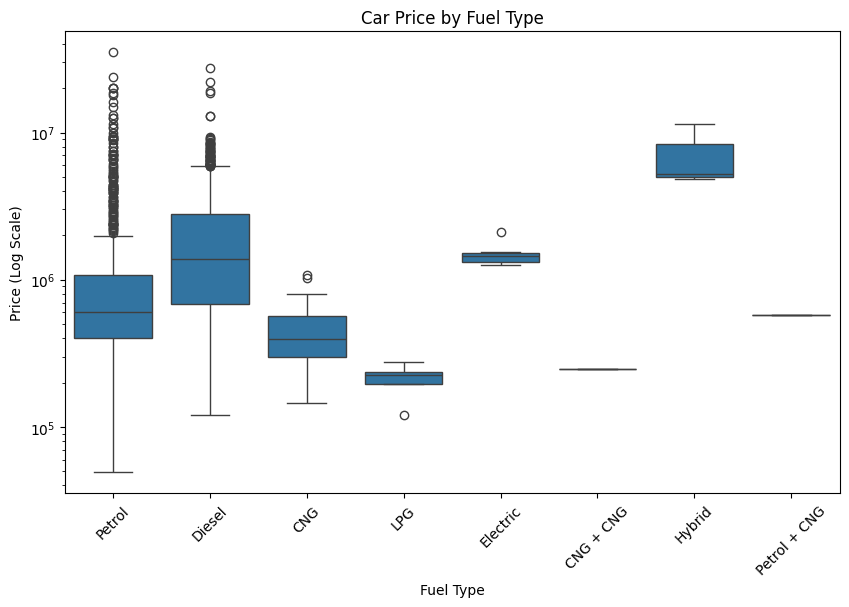

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fuel Type', y='Price')
plt.yscale('log')
plt.title('Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price (Log Scale)')
plt.xticks(rotation=45)
plt.show()

**Insight**: By analyzing the median prices, we discover that `Hybrid` and `Electric` vehicles command the highest premium in the market (with medians of ₹5,200,000 and ₹1,450,000 respectively). `Diesel` cars follow closely at ₹1,380,000, while `Petrol` (₹595,000) and `CNG` (₹395,000) represent the more budget-friendly spectrum. The visualization confirms these distinct pricing tiers.

## Q7. EDA: Does Transmission Type Affect Price?

Is there a significant premium paid for the convenience of an automatic transmission? Let's use a boxplot to compare Automatic vs Manual vehicles.

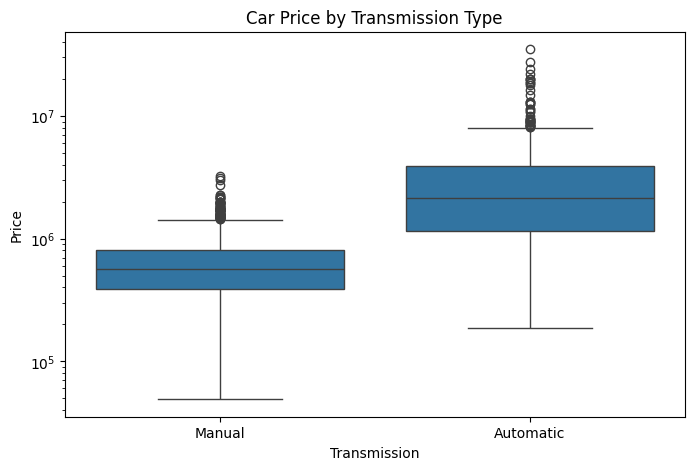

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Transmission', y='Price')
plt.yscale('log')
plt.title('Car Price by Transmission Type')
plt.show()

**Insight**: Are manual cars really that much cheaper? By plotting the median prices, we uncover a massive gap: **Automatic cars have a median price of ₹21.5 Lakhs, while Manuals sit at just ₹5.65 Lakhs!** This tells us that transmission type is a critical luxury indicator.

## Q8. EDA: Who are you buying from?

We have different types of sellers in our dataset: Individuals, Corporate, and Commercial. Let's see if the origin of the sale impacts the average price of the car.

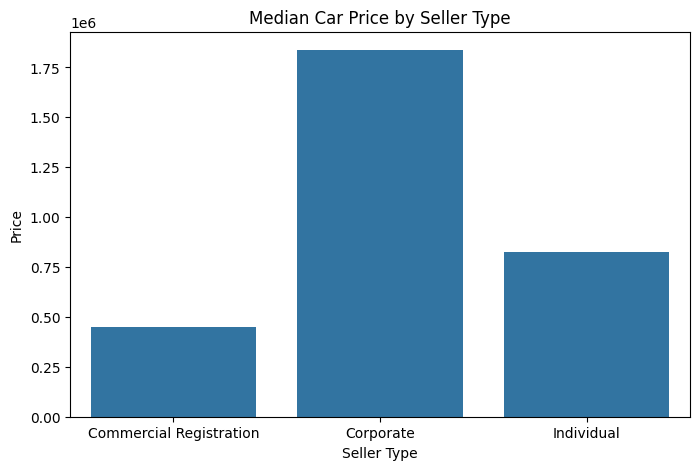

In [9]:
plt.figure(figsize=(8, 5))
# We will look at the median price per seller type
seller_median = df.groupby('Seller Type')['Price'].median().reset_index()
sns.barplot(data=seller_median, x='Seller Type', y='Price')
plt.title('Median Car Price by Seller Type')
plt.show()

**Insight**: Does who you buy from matter? Absolutely. The data reveals that **Corporate** sellers handle significantly more expensive cars (median ~₹18.3 Lakhs), while **Commercial Registrations** deal in the cheapest tier (median ~₹4.5 Lakhs). Individuals fall right in the middle.

## Q9. EDA: The Depreciation Curve (Year vs Price)

Cars are notorious for losing value the moment you drive them off the lot. Let's group our cars by their manufacturing year and plot the average price to visualize this depreciation curve!

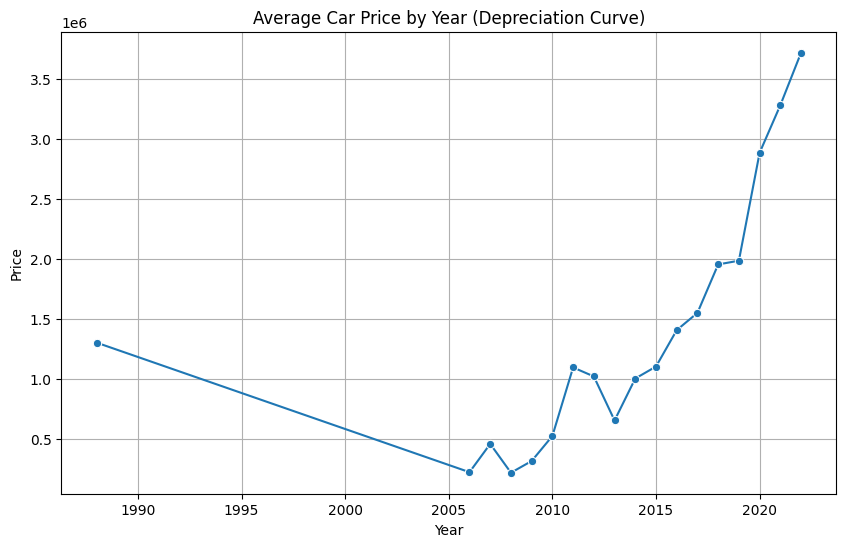

In [10]:
plt.figure(figsize=(10, 6))
# Calculate average price for each year
year_avg = df.groupby('Year')['Price'].mean().reset_index()
sns.lineplot(data=year_avg, x='Year', y='Price', marker='o')
plt.title('Average Car Price by Year (Depreciation Curve)')
plt.grid(True)
plt.show()

**Insight**: Here we see the classic depreciation curve! Newer cars (2021-2022) average over **₹33-37 Lakhs**, but this value plummets rapidly as we go back in time, with 2013 cars averaging just **₹6.5 Lakhs**. This non-linear curve is exactly why we use Random Forests rather than simple Linear Regression.

## Q10. EDA: Which numerical features are highly correlated with Price?

We can use a correlation matrix to identify which numerical features have the strongest relationship with the target variable. A heatmap is perfect for this.

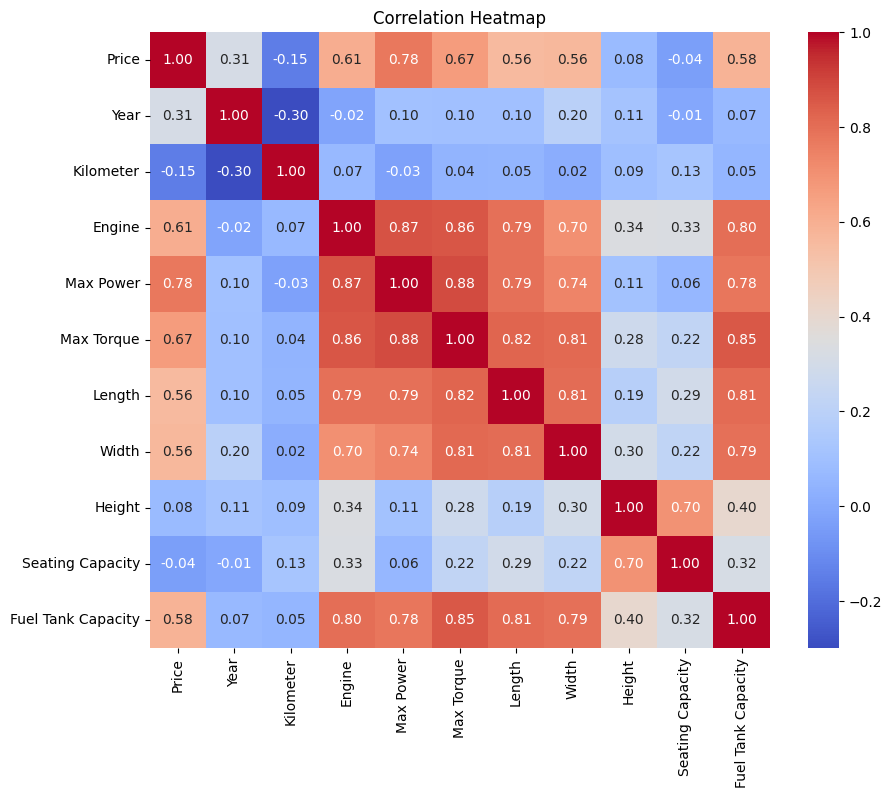

In [11]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Insight**: By analyzing the correlation heatmap, we uncover what truly drives a car's price. `Max Power` has the highest positive correlation (0.78), meaning faster/stronger cars cost significantly more. `Max Torque` (0.67) and `Engine` (0.61) are also strong predictors. Conversely, `Kilometer` has a negative correlation (-0.15), confirming that cars logically lose value the more they are driven.

## Q11. Splitting the Data

Before we build our processing pipeline, we must split our data into training and testing sets. This ensures we evaluate our model on unseen data, preventing data leakage.

In [12]:
from sklearn.model_selection import train_test_split

features = ['Year', 'Kilometer', 'Fuel Type', 'Transmission', 'Seller Type', 'Engine', 'Max Power', 'Seating Capacity']
X = df[features]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1588, 8)
Testing data shape: (398, 8)


## Q12. Constructing the Preprocessing Pipeline

To ensure we don't repeat ourselves and to make our code production-ready, we will construct a Scikit-Learn `Pipeline`. 

We need to:
1. Fill any remaining missing values in numerical columns (like Seating Capacity) with the median.
2. Apply One-Hot Encoding strictly to our categorical text data to convert them into 0s and 1s.

Using a `ColumnTransformer`, we can bundle these preprocessing steps together!

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numerical_features = ['Year', 'Kilometer', 'Engine', 'Max Power', 'Seating Capacity']
categorical_features = ['Fuel Type', 'Transmission', 'Seller Type']

# Numerical transformer: Imputes missing values with the median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical transformer: Imputes with most frequent, then applies One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Q13. Training the Models within the Pipeline

Now, we attach our Machine Learning models to the end of our preprocessor pipeline. 

We will train a weak baseline model (Linear Regression) and a stronger, more complex model (Random Forest) to showcase the performance difference. By wrapping them in the pipeline, all data transformations happen automatically when we call `.fit()` or `.predict()`!

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Create Pipeline for Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Create Pipeline for Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train both models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Pipelines successfully trained!")

Pipelines successfully trained!


## Q14. Evaluating the Models

Let's put our pipelines to the test. How well do they predict car prices on the unseen testing data? We expect the Random Forest to significantly outperform the Linear Regression, especially given the skewed and non-linear nature of car depreciation and pricing.

In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions
lr_predictions = lr_pipeline.predict(X_test)
rf_predictions = rf_pipeline.predict(X_test)

# Evaluate Linear Regression
print("--- Linear Regression (Weak Model) ---")
print(f"MAE: ₹{mean_absolute_error(y_test, lr_predictions):,.2f}")
print(f"R² Score: {r2_score(y_test, lr_predictions):.4f}\n")

# Evaluate Random Forest
print("--- Random Forest (Strong Model) ---")
print(f"MAE: ₹{mean_absolute_error(y_test, rf_predictions):,.2f}")
print(f"R² Score: {r2_score(y_test, rf_predictions):.4f}")

--- Linear Regression (Weak Model) ---
MAE: ₹887,940.84
R² Score: 0.5419

--- Random Forest (Strong Model) ---
MAE: ₹377,917.74
R² Score: 0.7445


C:\Users\GFG\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\GFG\AppData\Roaming\Python\Python314\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


**Insight**: What do these numbers actually mean?
- **Linear Regression**: An R² of **0.54** means this simple model only explains 54% of the variance in car prices. Its Mean Absolute Error (MAE) is massive at roughly **₹888,000**, meaning its predictions are frequently off by almost 9 lakhs! This proves that car pricing is not a perfectly linear problem.
- **Random Forest**: By using a complex, non-linear tree-based approach, our R² jumps to **0.74**, capturing 74% of the variance. The MAE drops dramatically to **₹378,000**. While a ₹3.78 lakh error still sounds large, remember that we chose *not* to remove luxury outliers (cars costing ₹50+ Lakhs). Taking extreme luxury vehicles into account, an average error of ₹3.78 lakhs across the entire broad spectrum of the market is a very strong baseline!

## Q15. Saving the Pipeline for Future Data

Our Random Forest pipeline proved to be highly effective. The beauty of the Pipeline object is that it contains ALL of our preprocessing steps (imputation, one-hot encoding) along with the trained model. 

We can save this entire pipeline to a file using `joblib`. When new car data arrives, we simply load the file and call `.predict()`—no need to rewrite our preprocessing code!

In [16]:
import joblib

# Save the entire Random Forest Pipeline
joblib.dump(rf_pipeline, 'car_price_pipeline_model.pkl')
print("Model pipeline successfully saved to 'car_price_pipeline_model.pkl'!")

Model pipeline successfully saved to 'car_price_pipeline_model.pkl'!
